# 5. Results and plots for paper

In [76]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [77]:
# Built-in
import os
import sys
import json
import datetime
import warnings

# Dependencies
import scipy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Internal methods
sys.path.append('../src')
import smbhb as smbhb
import bayes as bs
import utils as ut
import plots as pt
pt.setup()

In [78]:
# Hide warnings
warnings.filterwarnings("ignore")

In [167]:
# Global paths
path = Path('../')
ddir = path / 'data'
rdir = path / 'results'
fdir = path / 'figures'
c1 = 'lightseagreen'
c2 = 'b'
c3 = 'orange'
c4 = 'm'
cv = 'tomato'

In [80]:
scale = (1068.5 - 729.963465039166) / 1068.5
scale

0.31683344404383157

---
## 1. Bayesian inferences
---

In [107]:
# Load results for Plato
result_plato_Q   = ut.load_result(rdir / 'spikey_plato_jaxns_2yr24h_Q.npy')
result_plato_DM  = ut.load_result(rdir / 'spikey_plato_jaxns_2yr24h_DM.npy')
result_plato_QDM = ut.load_result(rdir / 'spikey_plato_jaxns_2yr24h_QDM.npy')

# Load results of Kepler
result_kepler_Q   = ut.load_result(rdir / 'spikey_kepler_jaxns_3yr24h_Q.npy')
result_kepler_DM  = ut.load_result(rdir / 'spikey_kepler_jaxns_3yr24h_DM.npy')
result_kepler_QDM = ut.load_result(rdir / 'spikey_kepler_jaxns_3yr24h_QDM.npy')

# Load results for Kepler+Plato
result_combined_Q   = ut.load_result(rdir / 'spikey_combined_jaxns_3yr2yr24h_Q.npy')
result_combined_DM  = ut.load_result(rdir / 'spikey_combined_jaxns_3yr2yr24h_DM.npy')
result_combined_QDM = ut.load_result(rdir / 'spikey_combined_jaxns_3yr2yr24h_QDM.npy')

---
### 1.1. Bayesian evidences

In [108]:
# Model evidences for Plato
#---------------------------
# Moddel QDM vs. Q
print(result_plato_QDM['logz'] - result_plato_Q['logz'], result_plato_QDM['logz_err']**2 + result_plato_Q['logz_err']**2) 
# Moddel Q vs. DM
print(result_plato_Q['logz'] - result_plato_DM['logz'], result_plato_Q['logz_err']**2 + result_plato_DM['logz_err']**2)
# Moddel QDM vs. DM
print(result_plato_QDM['logz'] - result_plato_DM['logz'],  result_plato_QDM['logz_err']**2 + result_plato_DM['logz_err']**2) 

68.36124674675193 0.020100728595934928
112.20834530650382 0.026627762900716334
180.56959205325575 0.03896366899516579


In [109]:
# Model evidences for Kepler
#---------------------------
# Moddel QDM vs. Q
print(result_kepler_QDM['logz'] - result_kepler_Q['logz'], result_kepler_QDM['logz_err']**2 + result_kepler_Q['logz_err']**2) 
# Moddel Q vs. DM
print(result_kepler_Q['logz'] - result_kepler_DM['logz'], result_kepler_Q['logz_err']**2 + result_kepler_DM['logz_err']**2)
# Moddel QDM vs. DM
print(result_kepler_QDM['logz'] - result_kepler_DM['logz'],  result_kepler_QDM['logz_err']**2 + result_kepler_DM['logz_err']**2) 

131.84973977945447 0.021055984566373805
1539.5737619569127 0.03402893577731448
1671.4235017363671 0.04592822759786941


In [110]:
# Model evidences for Kepler+Plato
#---------------------------
# Moddel QDM vs. Q
print(result_combined_QDM['logz'] - result_combined_Q['logz'], result_combined_QDM['logz_err']**2 + result_combined_Q['logz_err']**2) 
# Moddel Q vs. DM
print(result_combined_Q['logz'] - result_combined_DM['logz'], result_combined_Q['logz_err']**2 + result_combined_DM['logz_err']**2)
# Moddel QDM vs. DM
print(result_combined_QDM['logz'] - result_combined_DM['logz'],  result_combined_QDM['logz_err']**2 + result_combined_DM['logz_err']**2) 

197.76251697272255 0.029015802190770042
1898.896529419807 0.03765368645872513
2096.6590463925295 0.056883604658651166


---
### 1.2. Plot combined model fit

In [112]:
# Load Hu+2020 binned light curve of Spikey 
df_kepler = pd.read_feather(ddir / 'lc_spikey_kepler_smith2016.ftr')
Q0_kepler = 12

# Create a 1-d binned light curve and plot
df_kepler = ut.bin_lc(df_kepler, bin_size=1)
time_kepler = df_kepler.time.to_numpy()
flux_kepler = df_kepler.flux.to_numpy()

np.float64(6464.252209031665)

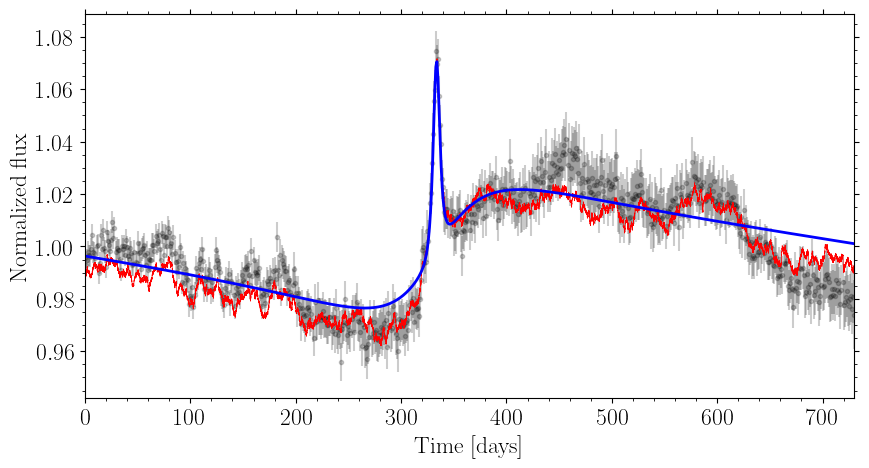

In [149]:
# Load Plato simulation and template of Spikey 
df_plato = pd.read_feather(ddir / 'lc_spikey_plato_fiducial.ftr')
dv_plato = pd.read_feather(ddir / 'lc_spikey_plato_template.ftr')
Q0_plato = 9

# Bin to 1-hour light curve 
df_plato = ut.bin_lc(df_plato, bin_size=1)

# Cut light curve to 2-year duration
df_plato = df_plato[df_plato.time < 4*ut.year2day()]

# Generate relativistic Spikey model
params = smbhb.model_params()
params.t0    = 0.712
params.sigma = 0 
model = smbhb.model(params)
dm_plato = model.light_curve(df_plato.time.to_numpy(), df=True)

# Set first exposure to zero
t0_offset = df_plato.time.iloc[0]
df_plato.time -= t0_offset
dv_plato.time -= t0_offset
dm_plato.time -= t0_offset

# Secure mean level
mean = np.mean(df_plato.flux) - 1
df_plato.flux -= mean

# Plot light curve
fig, ax = pt.plot_lc(df_plato, dv_plato, cm=cv, lw=0.5)
ax.plot(dm_plato.time, dm_plato.flux, '-', c=cm, lw=2);

# Add offset to Plato light curve
t0_kepler = 1.05
t0_plato  = 1.195
df_plato.time += (t0_plato - t0_kepler) * ut.year2day()
df_plato.time += 8 * smbhb._period_observed(params.P, params.z) * ut.year2day()
t0_comb = df_plato.time.iloc[0]
t0_comb

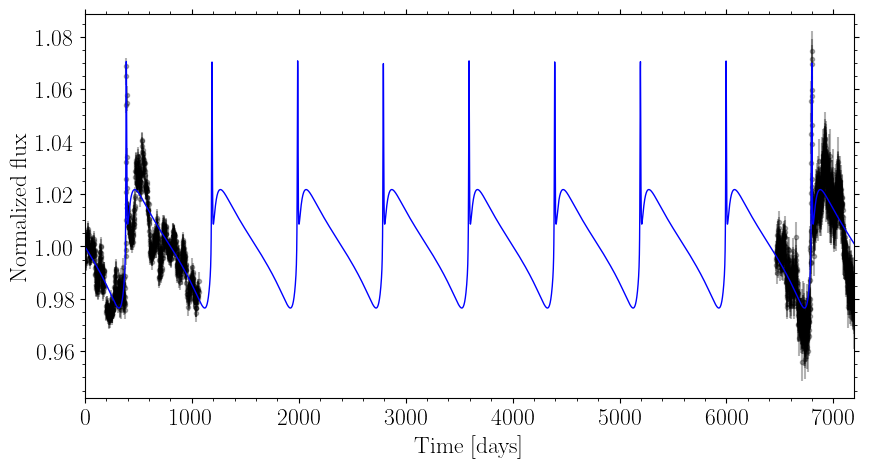

In [114]:
# Combine datasets
df_combined = pd.concat((df_kepler, df_plato))
time_combined = df_combined.time.to_numpy()
flux_combined = df_combined.flux.to_numpy()

# Generate relativistic Spikey model
params = smbhb.model_params()
params.sigma = 0 
params.seed  = params.seed
model = smbhb.model(params)
tm = np.arange(df.time.iloc[0], df.time.iloc[-1], 1)
dm = model.light_curve(tm, df=True)

# Plot merged light curves
fig, ax = pt.plot_lc(df, dm, cm=cm, lw=1, alpha=0.3)
# ax.set_xlim(6750, 6850)
# ax.set_xlim(360, 420)
# fig.savefig(odir/'lc_combined.png', bbox_inches='tight', dpi=200)

In [151]:
# Load Hu+2020 binned light curve of Spikey 
df_plato = pd.read_feather(ddir / 'lc_spikey_plato_fiducial.ftr')
dv_plato = pd.read_feather(ddir / 'lc_spikey_plato_template.ftr')
Q0_plato=9

# Bin to 1-hour light curve 
df_plato = ut.bin_lc(df_plato, bin_size=1)

# Cut light curve to 2-year duration (2 year of LOPS1)
df_plato = df_plato[df_plato.time < (2+2)*ut.year2day()]

# Secure mean level
df_plato.flux -= (np.mean(df_plato.flux) - 1)

# Reset time arrays
t0 = df_plato.time.iloc[0]
df_plato.time -= t0
dv_plato.time -= t0

# Store data
time_plato = df.time.to_numpy()
flux_plato = df.flux.to_numpy()

In [253]:
# Scales for figures below
size_kepler = 2*9 / (11 + 8) * 11
size_plato  = 2*9 - size_kepler

# scales for latex figures
size_kepler / 9, size_plato / 9

(1.1578947368421053, 0.8421052631578948)

---
### 1.3. *Kepler* model fit figure

In [203]:
# Create model fits
dm_kepler_Q    = bs.model_lightcurve_drw(time_kepler, result_kepler_Q)
dm_kepler_DM   = smbhb.model_lightcurve(time_kepler, result_kepler_DM['likelihood']['mle'])
dm_kepler_QDM  = bs.model_lightcurve_drw(time_kepler, result_kepler_QDM)
dm_combined_DM = smbhb.model_lightcurve(time_combined, result_combined_DM['likelihood']['mle'])

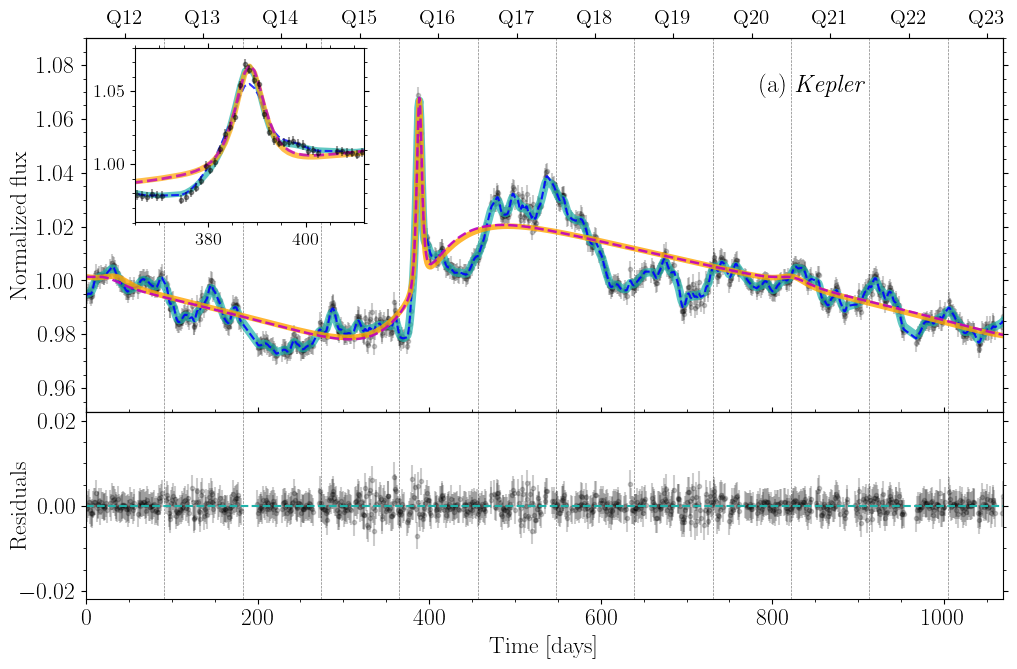

In [245]:
# Plot main plot
fig, ax = pt.plot_result(df_kepler, alpha=0.2,
                         dm=dm_kepler_QDM, cm=c1, lw=6, dm_alpha=0.7, 
                         Q0=12, xoff=-0.06, 
                         figsize=(size_kepler, 7))
ax[0].plot(time_kepler, dm_kepler_Q.flux,      '--', c=c2, lw=1.5, alpha=0.9);
ax[0].plot(time_kepler, dm_kepler_DM.flux,     '-',  c=c3, lw=4,   alpha=0.8);
ax[0].plot(time_combined, dm_combined_DM.flux, '--', c=c4, lw=1.8, alpha=0.9);
ax[0].text(785, 1.07, r'(a) \textit{Kepler}', fontsize=18);
ax[0].set_xlim(0, time_kepler[-1])
ax[0].set_ylim(0.951, 1.09)
ax[1].set_xlabel('Time [days]')
ax[1].set_xlim(0, time_kepler[-1])
ax[1].set_ylim(-0.022, 0.022)

# Zoom on SLF
zoomed_ax = plt.axes([0.138, 0.66, 0.22, 0.25])
zoomed_ax.errorbar(time_kepler, df_kepler.flux, df_kepler.flux_err, fmt='ok', ms=3, alpha=0.4, zorder=5)
zoomed_ax.plot(time_kepler, dm_kepler_QDM.flux,    '-',  c=c1, lw=4,   alpha=0.7);
zoomed_ax.plot(time_kepler, dm_kepler_Q.flux,      '--', c=c2, lw=1.5, alpha=0.8);
zoomed_ax.plot(time_kepler, dm_kepler_DM.flux,     '-',  c=c3, lw=4,   alpha=0.7);
zoomed_ax.plot(time_combined, dm_combined_DM.flux, '--', c=c4, lw=2,   alpha=0.8);
zoomed_ax.set_xlim(365, 412)
zoomed_ax.set_ylim(0.96, 1.08)
zoomed_ax.tick_params(axis='both', labelsize=13);

# Save figure
fig.savefig(fdir / 'modelfit_spikey_kepler.png', bbox_inches='tight', dpi=300)

---
### 1.4. *Plato* model light curve

In [246]:
time_combi = time_combined - t0_comb

In [247]:
# Show results of DM model
dm_plato_Q     = bs.model_lightcurve_drw(time_plato, result_plato_Q)
dm_plato_DM    = smbhb.model_lightcurve(time_plato, result_plato_DM['likelihood']['mle'])
dm_plato_QDM   = bs.model_lightcurve_drw(time_plato, result_plato_QDM)
dm_combined_DM = smbhb.model_lightcurve(time_combined, result_combined_DM['likelihood']['mle'])

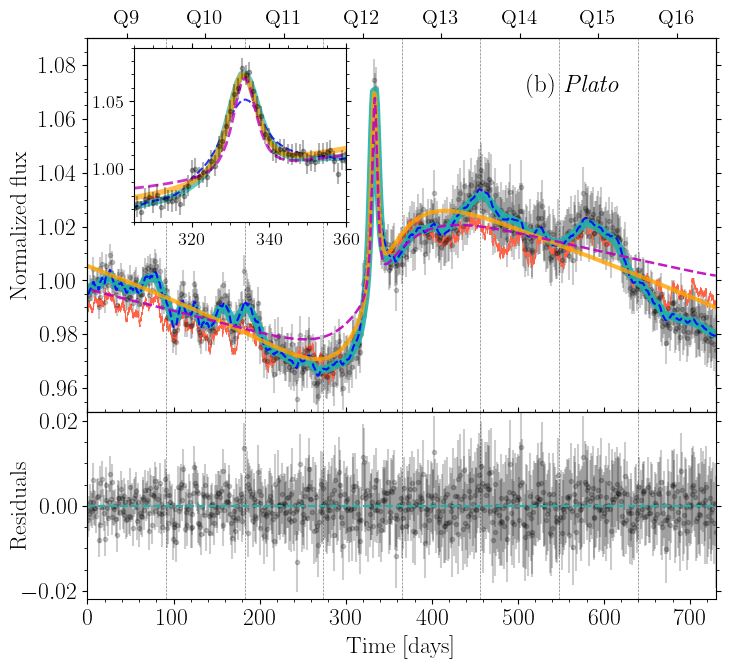

In [252]:
# Plot main plot
fig, ax = pt.plot_result(df_plato, dm=dm_plato_QDM, 
                         cm=c1, alpha=0.2, lw=6, dm_alpha=0.9,
                          Q0=Q0_plato, figsize=(size_plato, 7))
ax[0].plot(time_plato, dm_plato_Q.flux,     '--', c=c2, lw=1.5, alpha=0.9);
ax[0].plot(time_plato, dm_plato_DM.flux,    '-',  c=c3, lw=3,   alpha=0.8);
ax[0].plot(time_combi, dm_combined_DM.flux, '--', c=c4, lw=1.8, alpha=0.9);
ax[0].plot(dv.time, dv.flux, '-', c=cv, lw=0.5, zorder=1);
ax[0].text(511, 1.07, r'(b) \textit{Plato}', fontsize=18);
ax[0].set_ylim(0.951, 1.09)
ax[1].set_xlabel('Time [days]')
ax[1].set_ylim(-0.022, 0.022)

# Zoom on SLF
zoomed_ax = plt.axes([0.192, 0.66, 0.28, 0.25])
zoomed_ax.errorbar(time_plato, df_plato.flux, df_plato.flux_err, fmt='ok', ms=3, alpha=0.3, zorder=10)
zoomed_ax.plot(time_plato, dm_plato_QDM.flux,   '-',  c=c1, lw=5,   alpha=0.7);
zoomed_ax.plot(time_plato, dm_plato_Q.flux,     '--', c=c2, lw=1.5, alpha=0.8);
zoomed_ax.plot(time_plato, dm_plato_DM.flux,    '-',  c=c3, lw=4,   alpha=0.7);
zoomed_ax.plot(time_combi, dm_combined_DM.flux, '--', c=c4, lw=2,   alpha=0.8);
zoomed_ax.plot(dv.time, dv.flux,                '-',  c=cv, lw=1,   zorder=1);
zoomed_ax.set_xlim(305, 360)
zoomed_ax.set_ylim(0.96, 1.09)
zoomed_ax.tick_params(axis='both', labelsize=13);

# Save figure
fig.savefig(fdir / 'modelfit_spikey_plato.png', bbox_inches='tight', dpi=300)

---
## 2. Parameter variation plots
---

In [7]:
# def plot_parameter_variation(files, values, parameter, unit='', 
#                              fiducial=False, ofile=False):
#     # Load light curves of 1h cadence
#     dh1 = pd.read_feather(rdir / f'lc_spikey_{files[0]}_1h.ftr')
#     dh2 = pd.read_feather(rdir / f'lc_spikey_{files[1]}_1h.ftr')
#     dh3 = pd.read_feather(rdir / f'lc_spikey_{files[2]}_1h.ftr')
#     dh4 = pd.read_feather(rdir / f'lc_spikey_{files[3]}_1h.ftr')
#     dh_all = [dh1, dh2, dh3, dh4]
#     # Load light curves of 1d cadence
#     dd1 = pd.read_feather(rdir / f'lc_spikey_{files[0]}_1d.ftr')
#     dd2 = pd.read_feather(rdir / f'lc_spikey_{files[1]}_1d.ftr')
#     dd3 = pd.read_feather(rdir / f'lc_spikey_{files[2]}_1d.ftr')
#     dd4 = pd.read_feather(rdir / f'lc_spikey_{files[3]}_1d.ftr')
#     dd_all = [dd1, dd2, dd3, dd4]
#     # Load variable source injected
#     if fiducial:
#         dv = pd.read_feather(vdir / f'varsource_spikey_fiducial_components.ftr')
#         dv_all = [dv, dv, dv, dv]
#     else:
#         dv1 = pd.read_feather(vdir / f'varsource_spikey_{files[0]}_components.ftr')
#         dv2 = pd.read_feather(vdir / f'varsource_spikey_{files[1]}_components.ftr')
#         dv3 = pd.read_feather(vdir / f'varsource_spikey_{files[2]}_components.ftr')
#         dv4 = pd.read_feather(vdir / f'varsource_spikey_{files[3]}_components.ftr')
#         dv_all = [dv1, dv2, dv3, dv4]
#     # Plot variables
#     th = dh1.time
#     td = dd1.time
#     N = len(dh_all)
#     ah, ad = 0.1, 0.3
#     ch, cd, cv, cvm = 'k', 'gray', 'royalblue', 'orange'
#     # Plot magnitude dependence of Spikey
#     fig, ax = plt.subplots(N, 1, figsize=(8.5, 9))
#     for i, x, dh, dd, dv in zip(range(N), values, dh_all, dd_all, dv_all):
#         # Get proper models
#         fh, fh_err = (dh.flux - 1) * 1e3, dh.flux_err * 1e3
#         fd, fd_err = (dd.flux - 1) * 1e3, dd.flux_err * 1e3
#         tv, fv = dv.time / 86400, (dv.flux - 1) * 1e3
#         fv_model = (dv.flux_boost * dv.flux_lens - 1) * 1e3
#         # Plot all
#         if isinstance(x, float):
#             value = f'{x:.1f}'
#         else:
#             value = f'{x:.0f}'
#         ax[i].errorbar(th, fh, yerr=fh_err, fmt='.', c=ch, alpha=ah, zorder=1, 
#                        label=parameter + r' = ' + value + unit)
#         ax[i].errorbar(td, fd, yerr=fd_err, fmt='.', c=cd, alpha=ad, zorder=1)
#         ax[i].plot(tv, fv, '-', c=cv, lw=0.8)
#         ax[i].plot(tv, fv_model, '-', c=cvm, lw=1.5)
#         # Settings
#         ax[i].set_xlim(th.min(), th.max())
#         ax[i].legend(loc='upper center', fontsize=15)
#     # Add quarter marks
#     smbhb.plot_quarter_marks(ax, th.to_numpy(), N, Q0=1)
#     # Global settings
#     ax[N-1].set_xlabel('Time [days]')
#     fig.text(0.01, 0.5, 'Flux [ppt]', va='center', rotation='vertical')
#     plt.tight_layout(h_pad=0)
#     fig.subplots_adjust(hspace=0)
#     # Extra for magnitude
#     if fiducial == 'mag':
#         ax[-1].set_ylim(-170, 170)
#     # Save figure
#     if ofile:
#         fig.savefig(ofile, bbox_inches='tight', dpi=200)

### Plato magnitude, $\mathcal{P}$

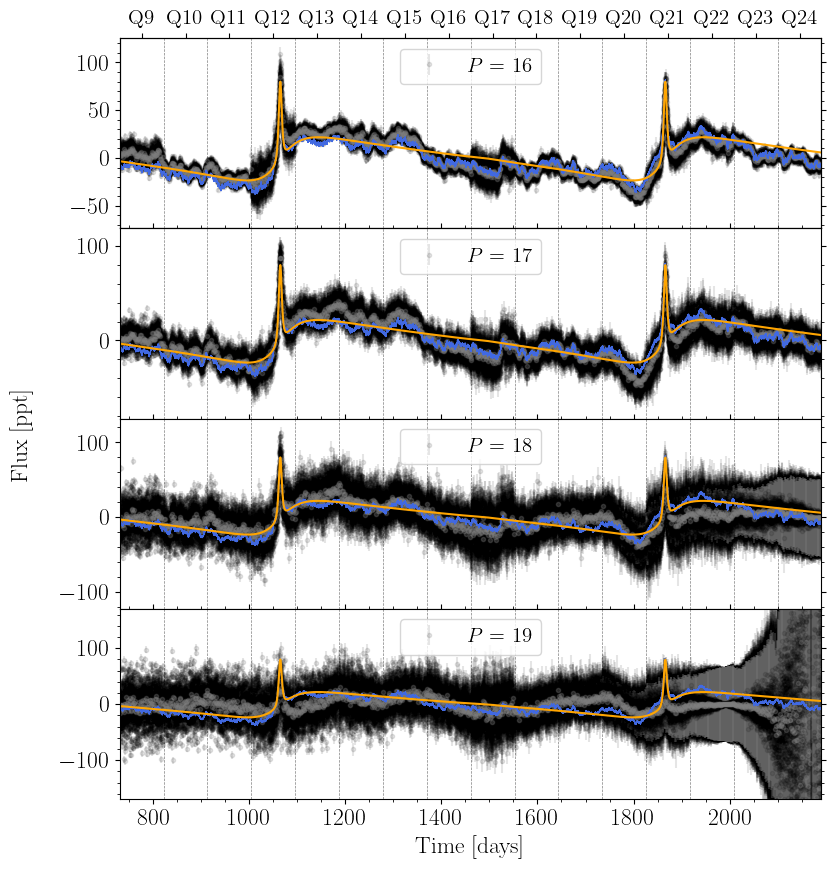

In [13]:
files  = ['mag16', 'mag17', 'mag18', 'mag19']
values = [16, 17, 18, 19]
ofile  = 'lc_mag.png'
pt.plot_parameter_variation(path, files, values, r'$P$', fiducial='mag', ofile=ofile);

### Inclination, $i$

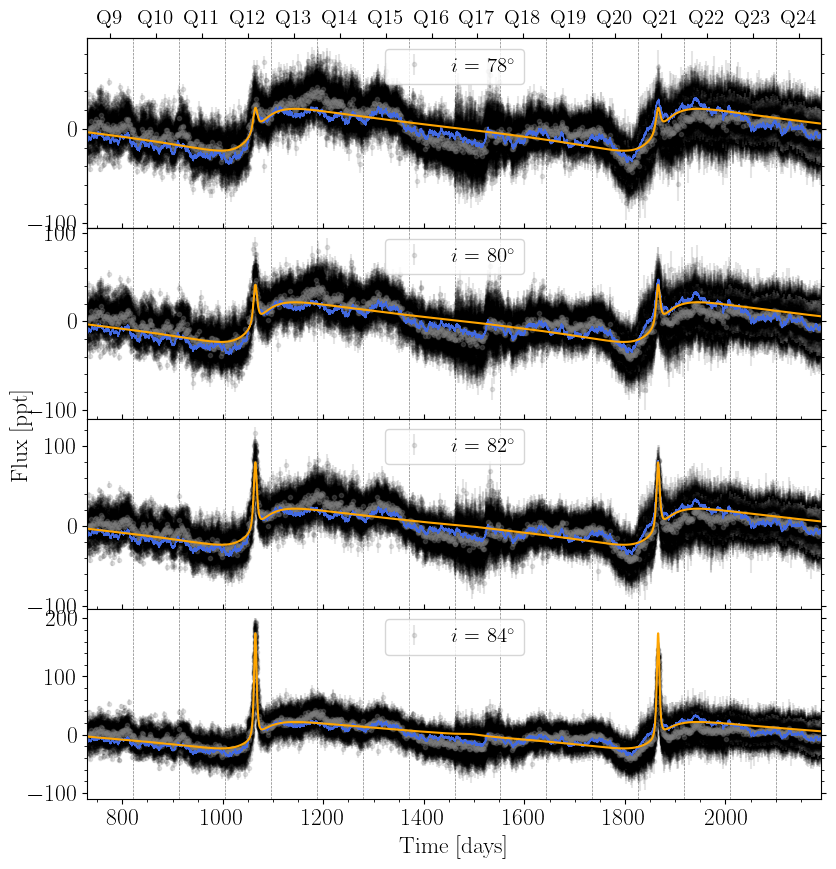

In [14]:
files  = ['i78', 'i80', 'fiducial', 'i84']
values = [78, 80, 82, 84]
ofile  = 'lc_inclination.png'
pt.plot_parameter_variation(path, files, values, r'$i$', r'$^{\circ}$', ofile=ofile);

### Argument of periapse, $\omega$

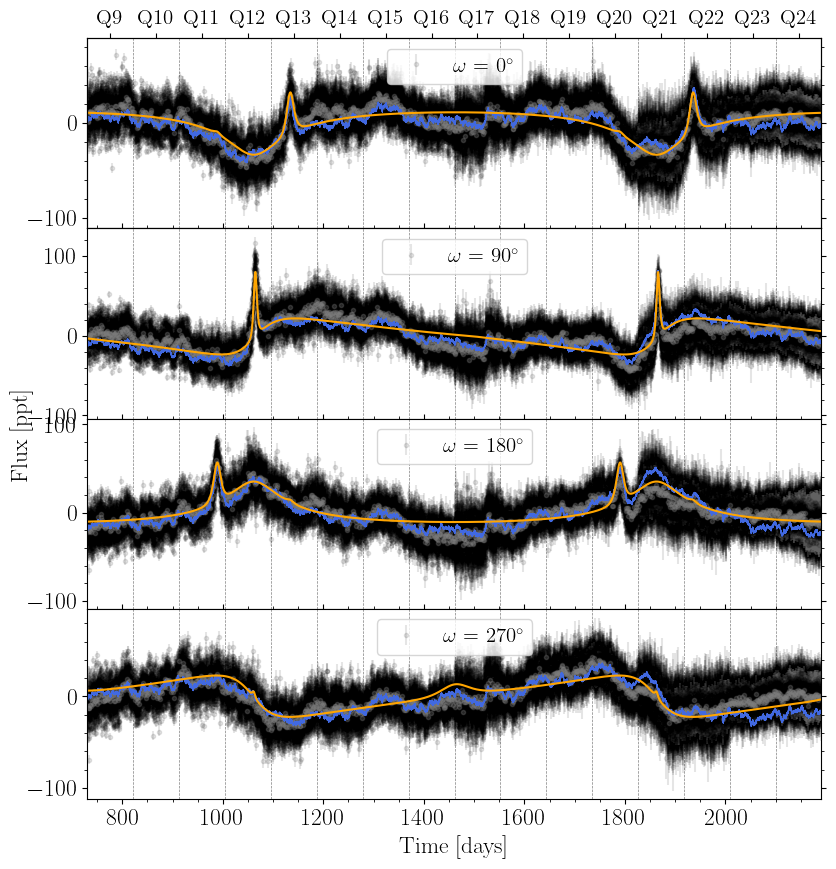

In [15]:
files  = ['w000', 'fiducial', 'w180', 'w270']
values = [0, 90, 180, 270]
ofile  = 'lc_omega.png'
pt.plot_parameter_variation(path, files, values, r'$\omega$',  r'$^{\circ}$', ofile=ofile);

### Eccentricity, $e$

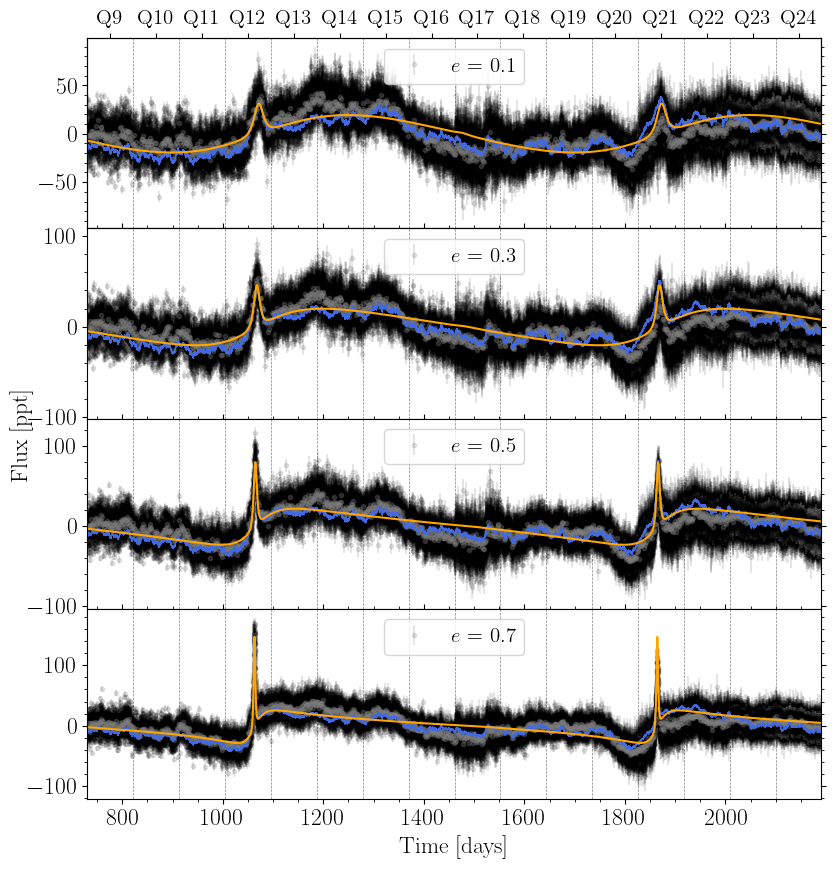

In [17]:
files  = ['e01', 'e03', 'fiducial', 'e07']
values = [0.1, 0.3, 0.5, 0.7]
ofile  = 'lc_eccentricity.png'
pt.plot_parameter_variation(path, files, values, r'$e$', ofile=ofile);

### DRW amplitude,  $\text{SF}_\infty$

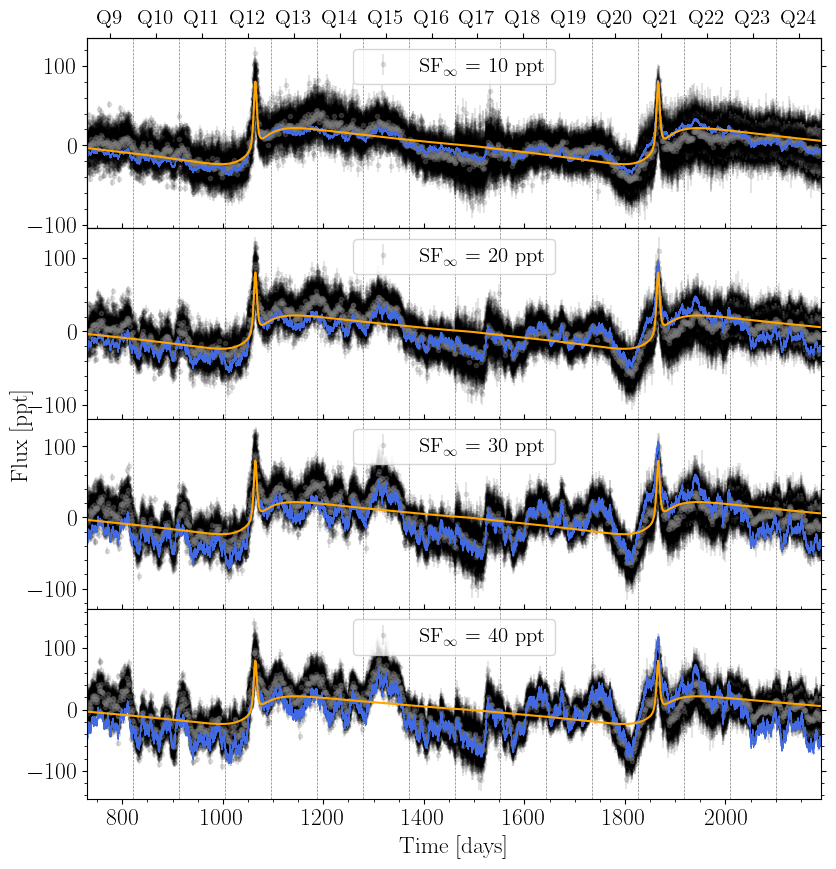

In [18]:
files  = ['fiducial', 'sigma20', 'sigma30', 'sigma40']
values = [10, 20, 30, 40]
ofile  = 'lc_sigma.png'
pt.plot_parameter_variation(path, files, values, r'SF$_\infty$', ' ppt', ofile=ofile);

### DRW amplitude,  $\text{SF}_\infty$ ($\tau = 10$ days)

<IPython.core.display.Javascript object>


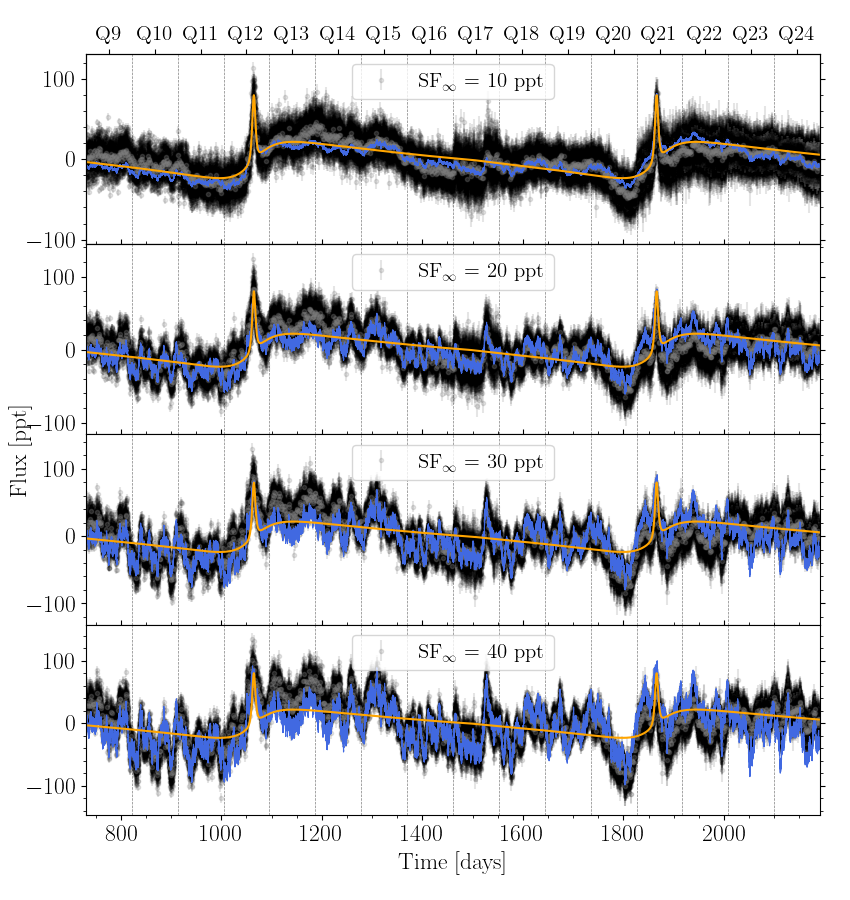

In [165]:
files  = ['fiducial', 'tau10_sigma20', 'tau10_sigma30', 'tau10_sigma40']
values = [10, 20, 30, 40]
ofile  = 'lc_sigma_tau10.png'
pt.plot_parameter_variation(path, files, values, r'SF$_\infty$', ' ppt', ofile=ofile);

### Plot for paper showing highest chance of DRW signal confusion 

<IPython.core.display.Javascript object>


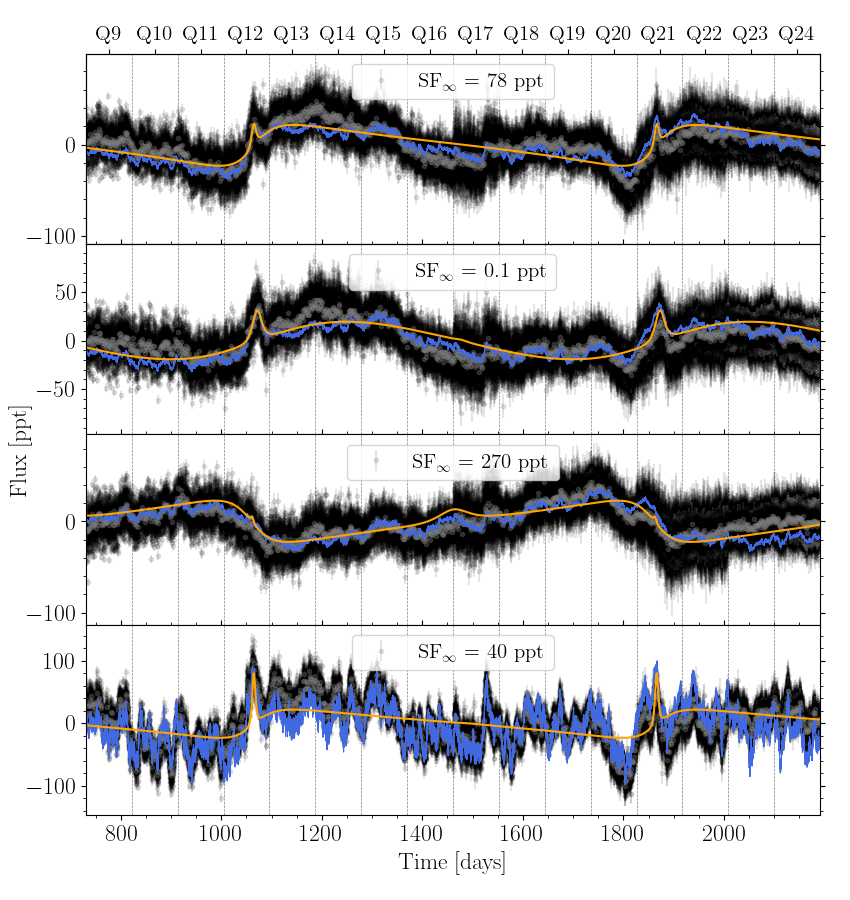

In [171]:
files = ['i78', 'e01', 'w270', 'tau10_sigma40']
values = [78, 0.1, 270, 40]
ofile = fdir / f'lc_wcs.png'
plot_parameter_variation(files, values,  r'SF$_\infty$', ' ppt', ofile=ofile)

---
## Plot model parmater recovery 
---

In [87]:
xlab = [r'$t0$', r'$P$', r'$i$', r'$e$', r'$\omega$', r'$\log M_1$', r'$\log M_2$', '$L$', r'$\alpha$']


In [4]:
# from matplotlib.ticker import MaxNLocator

# numPlotsY = 7
# numPlotsX = 9
# f, ax_grid = plt.subplots(numPlotsY,numPlotsX, sharex=False, sharey=False, figsize=(14,8))

# # A = np.arange(numPlotsY)+1.0
# # phi = np.arange(numPlotsX)
# # x = np.linspace(0,2.0,100)
# fontsize = 18

# for y_i in range(numPlotsY):
#     for x_i in range(numPlotsX):
# #         y = A[y_i]*np.sin(x*np.pi + phi[x_i])
#         ax = ax_grid[y_i,x_i]
# #         ax.axvline(x=0, color='r', ls='--') #plot(x,y,lw=2.0)
#         ax.plot(1, 1, 'ro')
#         # If left-most column:  Remove all overlapping y-ticks
#         # Else:                 Remove all ticks
#         if x_i == 0:
#             ax.set_ylabel(r'$y$', fontsize=fontsize)
#             # If top left subplot:      Remove bottom y-tick
#             # If bottom left subplot:   Remove top y-tick
#             # Else:                     Remove top and bottom y-ticks
#             if y_i == 0:
#                 nbins = len(ax.get_yticklabels())
#                 ax.yaxis.set_major_locator(MaxNLocator(nbins=nbins,prune='lower'))
#             elif y_i == numPlotsY-1:
#                 nbins = len(ax.get_yticklabels())
#                 ax.yaxis.set_major_locator(MaxNLocator(nbins=nbins,prune='upper'))
#             else:
#                 nbins = len(ax.get_yticklabels())
#                 ax.yaxis.set_major_locator(MaxNLocator(nbins=nbins,prune='both'))
#         else:
#             ax.yaxis.set_ticks([])

#         # If bottom row:    Remove all overlapping x-ticks
#         # Else:             Remove all ticks
#         if y_i == numPlotsY-1:
#             pass
#         else:
#             ax.xaxis.set_ticks([])

#         if y_i == 0:
#             ax.set_title(xlab[x_i], fontsize=fontsize)

# f.subplots_adjust(wspace=0,hspace=0)
# # plt.suptitle(r'$A\cdot\sin\left(2\pi x + \phi\right)$',fontsize=18)
# plt.show()